# AGENTE LRTA*
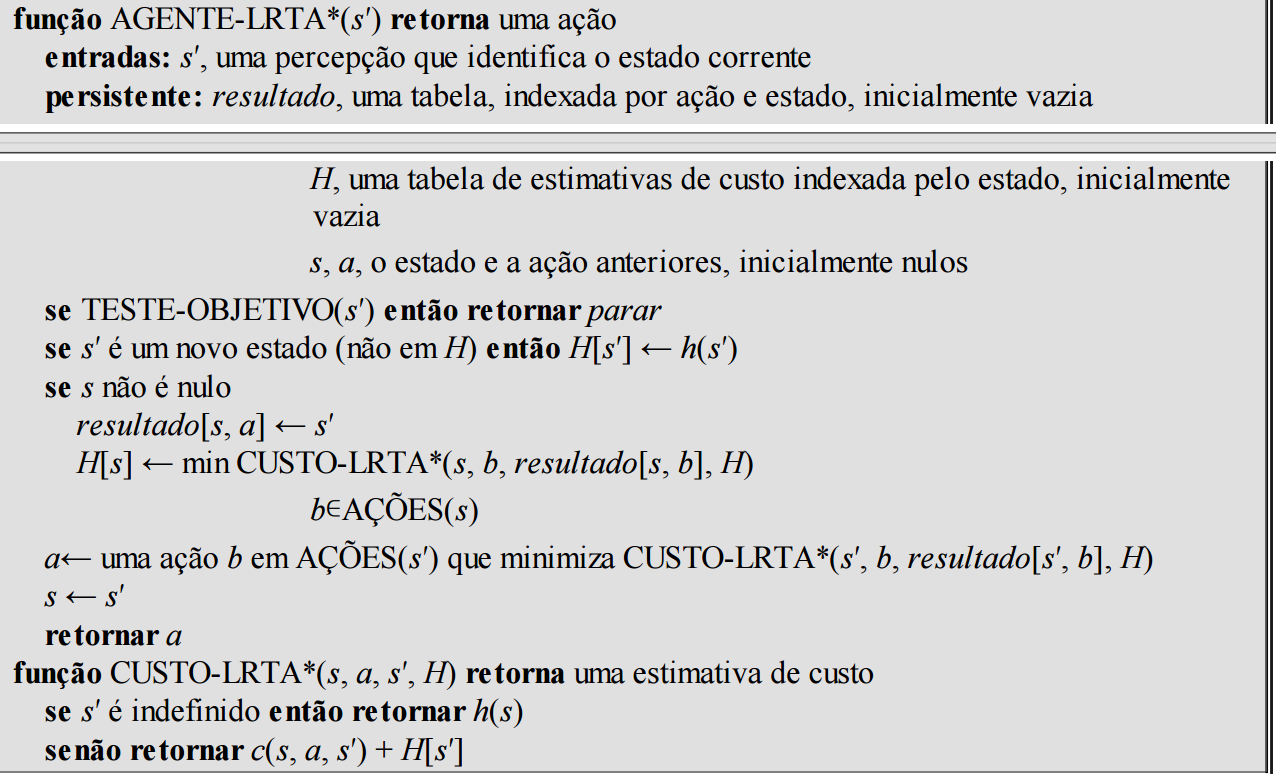

In [1]:
class AgenteLRTAStar:
    def __init__(self, acoes_func, custo_func, heuristica, teste_objetivo):
        """
        acoes_func(s) -> lista de ações
        custo_func(s, a, s') -> custo da ação
        heuristica(s) -> h(s)
        teste_objetivo(s) -> True/False
        """

        self.acoes_func = acoes_func
        self.custo_func = custo_func
        self.h = heuristica
        self.teste_objetivo = teste_objetivo

        # Estruturas persistentes
        self.resultado = {}  # (s, a) -> s'
        self.H = {}          # s -> valor heurístico aprendido

        self.s = None  # estado anterior
        self.a = None  # ação anterior

    def custo_lrta(self, s, a, s_linha):
        if s_linha is None:
            return self.h(s)
        else:
            return self.custo_func(s, a, s_linha) + self.H[s_linha]

    def agir(self, s_linha):
        # TESTE-OBJETIVO
        if self.teste_objetivo(s_linha):
            return None  # parar

        # Se estado novo
        if s_linha not in self.H:
            self.H[s_linha] = self.h(s_linha)

        # Atualiza estado anterior
        if self.s is not None:
            self.resultado[(self.s, self.a)] = s_linha

            # Atualiza heurística do estado anterior
            custos = []
            for b in self.acoes_func(self.s):
                s_result = self.resultado.get((self.s, b))
                custos.append(self.custo_lrta(self.s, b, s_result))

            self.H[self.s] = min(custos)

        # Escolhe melhor ação no estado atual
        melhor_acao = None
        melhor_custo = float('inf')

        for b in self.acoes_func(s_linha):
            s_result = self.resultado.get((s_linha, b))
            custo = self.custo_lrta(s_linha, b, s_result)

            if custo < melhor_custo:
                melhor_custo = custo
                melhor_acao = b

        self.a = melhor_acao
        self.s = s_linha

        return self.a

In [2]:
grafo = {
    'A': ['B', 'C'],
    'B': ['A', 'D'],
    'C': ['A'],
    'D': []
}

def acoes(s):
    return grafo[s]

def custo(s, a, s_linha):
    return 1  # custo uniforme

def heuristica(s):
    h_vals = {
        'A': 2,
        'B': 1,
        'C': 2,
        'D': 0
    }
    return h_vals[s]

def objetivo(s):
    return s == 'D'

agente = AgenteLRTAStar(acoes, custo, heuristica, objetivo)

estado = 'A'

for i in range(10):
    acao = agente.agir(estado)

    if acao is None:
        print("Chegou no objetivo:", estado)
        break

    print(f"{estado} -> {acao}")

    # simula movimento
    estado = acao

A -> B
B -> A
A -> B
B -> D
Chegou no objetivo: D
